# Final Project - Walmart Data Analysis

**What influences sales. We want some inventory decision making so that we can optimize our stocking**

Dependent Variable:
Weekly Sales Revenue
- strongest business relevance,
- easiest executive storytelling,
- supports all required models,
- easier visualizations,
- cleaner forecasting,
 - and usually better model performance.

Analysis Includes:
regression models predicting sales,
random forest models identifying demand drivers,
and time series forecasts for future inventory planning. 

In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [278]:
df = pd.read_csv('Walmart.csv')
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Unnamed: 15,Unnamed: 16
0,1/1/2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,NaN,NaN
1,1/1/2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,NaN,NaN
2,1/1/2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,NaN,NaN
3,1/1/2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,NaN,NaN
4,1/1/2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,NaN,NaN


# Data Cleaning and Prep
Drop columns that were imported but don't contain data. 

In [279]:
df = df.iloc[:, :-2]
df.columns = df.columns.str.strip()
df.drop(columns=['Demand Forecast'], inplace=True)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,1/1/2022,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,1/1/2022,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,1/1/2022,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,1/1/2022,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,1/1/2022,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer


In [280]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Create date-based features for modeling - added to help with modeling after 
# trying it without initially
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

**Check for null values**

In [281]:
df.isnull().values.any()

np.False_

**Check for outliers and overall data scan**

In [282]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Price               73100 non-null  float64       
 9   Discount            73100 non-null  int64         
 10  Weather Condition   73100 non-null  str           
 11  Holiday/Promotion   73100 non-null  int64         
 12  Competitor Pricing  73100 non-null  float64       
 13  Seasonality         73100 non-null  str           
 14  Y

**Outlier check outliers based on 1.5 IQR Above or Below**

In [283]:
numeric_df = df.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outliers.sum()

Inventory Level         0
Units Sold            715
Units Ordered           0
Price                   0
Discount                0
Holiday/Promotion       0
Competitor Pricing      0
Year                    0
Month                   0
DayOfWeek               0
dtype: int64

In [284]:
from scipy.stats import zscore
import numpy as np

z = np.abs(zscore(df.select_dtypes(include=[np.number])))
outliers = (z > 3)

np.sum(outliers, axis=0)

array([  0, 236,   0,   0,   0,   0,   0,   0,   0,   0])

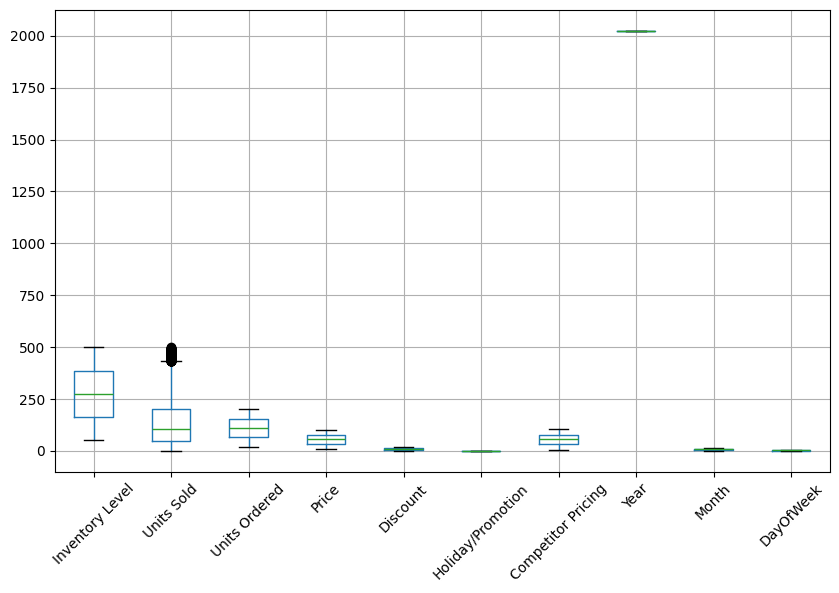

In [285]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

In [286]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing',
       'Seasonality', 'Year', 'Month', 'DayOfWeek'],
      dtype='str')

In [287]:
numeric_cols = [
    'Inventory Level',
    'Units Sold',
    # 'Demand Forecast',
    'Holiday/Promotion',
    'Units Ordered',
    'Price',
    'Discount',
    'Competitor Pricing'
]

**Added log_units_sold to see if the helps with outliers. The data seems valid, I want to see if the log value is beneficial.**

In [288]:
df['log_units_sold'] = np.log1p(df['Units Sold'])

**Ensure Discount is not a negitive value**

In [289]:
df[(df['Discount'] < 0)]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,DayOfWeek,log_units_sold


In [290]:
import pandas as pd

pd.set_option('display.max_rows', None)

df[outliers.any(axis=1)]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,DayOfWeek,log_units_sold
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,70.99,10,Snowy,0,72.93,Summer,2022,1,6,6.142037
138,2022-01-02,S002,P0019,Toys,East,492,479,132,79.11,0,Cloudy,0,80.06,Winter,2022,1,6,6.173786
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,20.66,0,Rainy,1,16.87,Winter,2022,1,3,6.167516
750,2022-01-08,S003,P0011,Furniture,East,482,480,68,74.14,20,Snowy,0,73.20,Winter,2022,1,5,6.175867
1512,2022-01-16,S001,P0013,Furniture,South,482,482,62,62.11,5,Rainy,0,61.24,Summer,2022,1,6,6.180017
1948,2022-01-20,S003,P0009,Toys,South,495,469,165,27.14,10,Cloudy,1,28.59,Autumn,2022,1,3,6.152733
1949,2022-01-20,S003,P0010,Groceries,North,482,471,144,10.73,5,Snowy,1,10.81,Spring,2022,1,3,6.156979
2023,2022-01-21,S002,P0004,Electronics,East,488,476,37,32.05,15,Sunny,0,36.50,Autumn,2022,1,4,6.167516
2151,2022-01-22,S003,P0012,Groceries,North,484,482,141,56.00,5,Rainy,0,52.78,Spring,2022,1,5,6.180017
2306,2022-01-24,S001,P0007,Electronics,East,466,466,133,86.56,5,Rainy,0,90.71,Autumn,2022,1,0,6.146329


**Convert the date column into a time series** 

In [291]:
df['Date'] = pd.to_datetime(df['Date'])

df.groupby('Date')['Units Sold'].sum().plot(figsize=(12,5))

<Axes: xlabel='Date'>

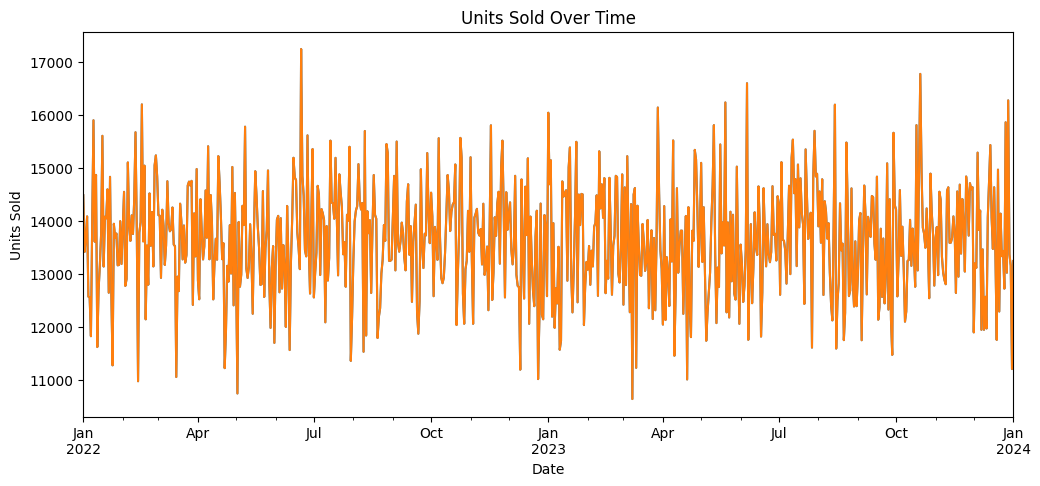

In [292]:
import matplotlib.pyplot as plt

df.groupby('Date')['Units Sold'].sum().plot(figsize=(12,5))
plt.title("Units Sold Over Time")
plt.ylabel("Units Sold")
plt.xlabel("Date")
plt.show()

# Set Dependent and Independent Variables

In [293]:
y = df['Units Sold']

X = df.drop(columns=['Units Sold', 'Date'])

# Fix Residuals 
**- found issues in the residuals - so came back to add this squared method to fix it.** 

Residual diagnostics indicated nonlinearity in the model. To address this, polynomial and interaction terms (e.g., price² and price × discount) were introduced. This improved model fit and reduced systematic patterns in residuals.”

In [294]:
X = df.drop(columns=['Units Sold', 'Date'])
X = pd.get_dummies(X, drop_first=True)

# Convert Categorical Values
- Get Dummies

In [295]:
X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

**Check for normality**

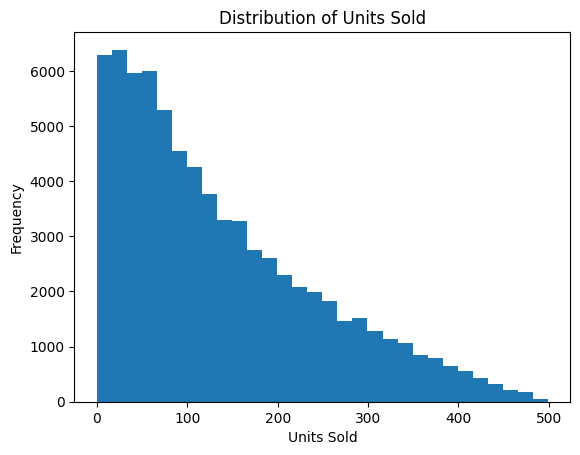

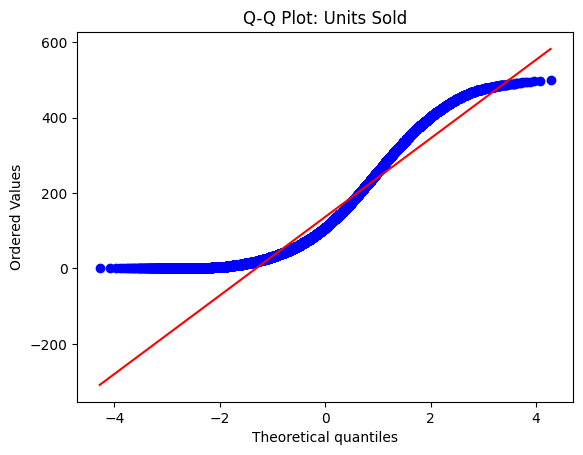

Skewness of Units Sold: 0.9053326253493985


In [296]:
plt.hist(y, bins=30)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

stats.probplot(y, dist="norm", plot=plt)
plt.title("Q-Q Plot: Units Sold")
plt.show()

print("Skewness of Units Sold:", y.skew())

**Log transform to help with normality issue - not great but good enouth. **

Q-Q Plot
That curve shape (S-shape)... not normal, the flat lower tail is due to a lots of zeros and will need to check residuals closely. 

Histogram
Right-skewed is better, but not great. It is not symatrically or bell-shaped. There is lot of zeros or very small values. 

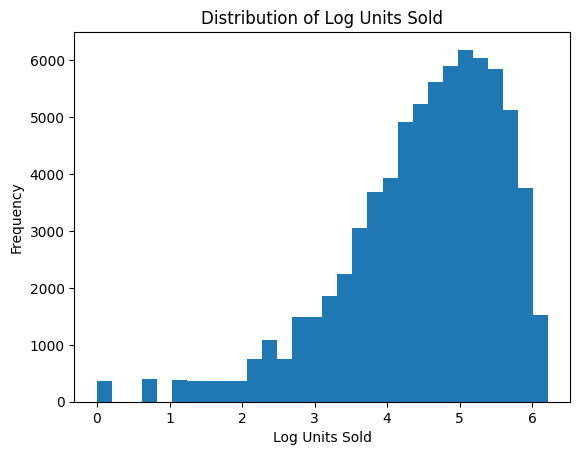

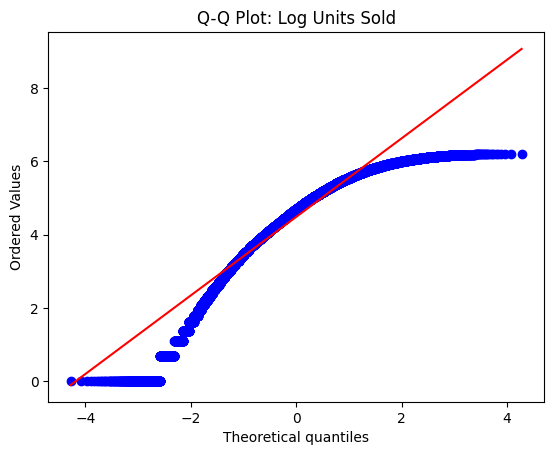

Skewness of Log Units Sold: -1.1149201138365896


In [297]:
df['log_units_sold'] = np.log1p(df['Units Sold'])

y_log = df['log_units_sold']

plt.hist(y_log, bins=30)
plt.title("Distribution of Log Units Sold")
plt.xlabel("Log Units Sold")
plt.ylabel("Frequency")
plt.show()

stats.probplot(y_log, dist="norm", plot=plt)
plt.title("Q-Q Plot: Log Units Sold")
plt.show()

print("Skewness of Log Units Sold:", y_log.skew())

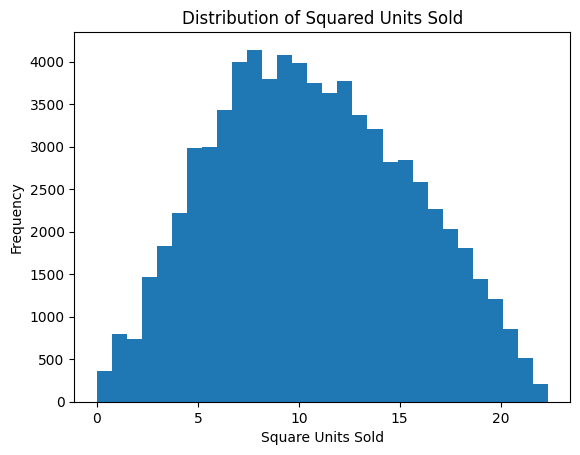

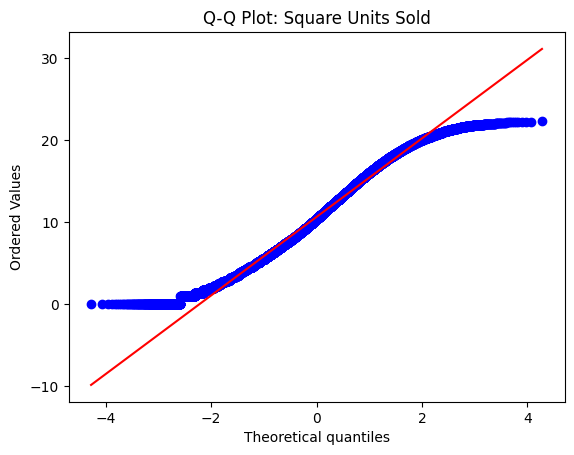

Skewness of Square Units Sold: 0.13521001730548227


In [298]:
df['UnitsSold_Sqrt'] = np.sqrt(df['Units Sold'])
ySquared = df['UnitsSold_Sqrt']

plt.hist(ySquared, bins=30)
plt.title("Distribution of Squared Units Sold")
plt.xlabel("Square Units Sold")
plt.ylabel("Frequency")
plt.show()

stats.probplot(ySquared, dist="norm", plot=plt)
plt.title("Q-Q Plot: Square Units Sold")
plt.show()

print("Skewness of Square Units Sold:", ySquared.skew())

# Start the Stepwise Process - split test/train - using Leave K out because we'll be doing time series. 

- A time-based train-test split was used across all models to preserve temporal ordering and prevent data leakage. This ensures model performance reflects real-world forecasting conditions so I want the same 

In [299]:
# Sort the full dataframe first
df = df.sort_values('Date').reset_index(drop=True)

# Recreate log target AFTER sorting
df['UnitsSold_Sqrt'] = np.sqrt(df['Units Sold'])

y_squared = df['UnitsSold_Sqrt']

# Recreate X AFTER sorting
X = df.drop(columns=['Units Sold', 'UnitsSold_Sqrt', 'Date', 'log_units_sold'])

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Make sure all X values are numeric
X = X.astype(float)

# Time-based split
split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y_squared.iloc[:split_index]
y_test  = y_squared.iloc[split_index:]


In [300]:
def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.10):
    included = []
    
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pvals = pd.Series(index=excluded, dtype=float)
        
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_col]])).fit()
            new_pvals[new_col] = model.pvalues[new_col]
        
        if not new_pvals.empty:
            best_pval = new_pvals.min()
            if best_pval < threshold_in:
                best_feature = new_pvals.idxmin()
                included.append(best_feature)
                changed = True
                print(f"Add {best_feature} with p-value {best_pval:.6f}")
        
        # Backward step
        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                print(f"Drop {worst_feature} with p-value {worst_pval:.6f}")
        
        if not changed:
            break
    
    return included

selected_features = stepwise_selection(X_train, y_train)

print("\nSelected Features:")
print(selected_features)

Add Inventory Level with p-value 0.000000

Selected Features:
['Inventory Level']


In [301]:
# Overall this is only suggesting inventory level which is not a multiple linear 
# regression, rather it is a simple linear regression. Going to try using the 
# best subset method instead 

In [302]:
# Check Best Subset Approach for MLR

In [303]:
import itertools
import pandas as pd
import statsmodels.api as sm
import numpy as np

y = df['Units Sold']

# Potential independent variables
X = df[[
    'Inventory Level',
    'Holiday/Promotion',
    'Units Ordered',
    'Price',
    'Discount',
    'Competitor Pricing'
    ]]

results = []

for k in range(1, len(X.columns) + 1):

    for combo in itertools.combinations(X.columns, k):

        X_subset = X[list(combo)]

        X_subset = sm.add_constant(X_subset)

        model = sm.OLS(y_squared, X_subset).fit()

        results.append({
            'Variables': combo,
            'Adjusted_R2': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic
        })

results_df = pd.DataFrame(results)

# Sort by Adjusted R²
results_df = results_df.sort_values(
    by='Adjusted_R2',
    ascending=False
)

print(results_df.head(10))

                                            Variables  Adjusted_R2  \
8                            (Inventory Level, Price)     0.327092   
10              (Inventory Level, Competitor Pricing)     0.327092   
25            (Inventory Level, Units Ordered, Price)     0.327085   
22        (Inventory Level, Holiday/Promotion, Price)     0.327085   
27  (Inventory Level, Units Ordered, Competitor Pr...     0.327085   
24  (Inventory Level, Holiday/Promotion, Competito...     0.327084   
28                 (Inventory Level, Price, Discount)     0.327083   
29       (Inventory Level, Price, Competitor Pricing)     0.327083   
30    (Inventory Level, Discount, Competitor Pricing)     0.327083   
41  (Inventory Level, Holiday/Promotion, Units Ord...     0.327078   

              AIC            BIC  
8   408522.638507  408550.237258  
10  408522.681740  408550.280491  
25  408524.404583  408561.202917  
22  408524.442095  408561.240429  
27  408524.448371  408561.246705  
24  408524.484689  

In [304]:
# Choosing Inventory Level and Price as my best multiple linear regression. It has
# the lowest AIC and BIC scores. Also it provides multiple independent variables
# Now fitting the model

In [305]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

y = df['Units Sold']

X = df[['Inventory Level', 'Price']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

feature_names = poly.get_feature_names_out(X.columns)

X_poly_df = pd.DataFrame(
    X_poly,
    columns=feature_names
)

X_poly_df = sm.add_constant(X_poly_df)

model = sm.OLS(y, X_poly_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Units Sold   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     7808.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        11:25:34   Log-Likelihood:            -4.3097e+05
No. Observations:               73100   AIC:                         8.619e+05
Df Residuals:                   73094   BIC:                         8.620e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   136.81

In [306]:
# Check Hypothesis testing through P-values

In [308]:
print(model.pvalues)

alpha = 0.05

if model.f_pvalue < alpha:
    print("Reject H0: Model is statistically significant")
else:
    print("Fail to reject H0")

const                    0.000000
Inventory Level          0.000000
Price                    0.148806
Inventory Level^2        0.333739
Inventory Level Price    0.120575
Price^2                  0.993513
dtype: float64
Reject H0: Model is statistically significant


In [ ]:
# Ananlysis
# Due to the inventory level p value is at 0, this concludes that
# there is a less than 5% probability that the observed results occurred 
# by random chance alone. We will reject the null hypothesis.
# Proving this model is statistically significant

# Check Model Performance

In [254]:
y = df['Units Sold']

X = X_poly_df

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=16
)

final_model = sm.OLS(y_train, X_train).fit()

y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Test R-squared:", r2)
print("Test RMSE:", rmse)

Test R-squared: 0.35419918763852176
Test RMSE: 86.92907436946379


# Cross Validation 

In [255]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression

X_train_selected = X_train[selected_features]

tscv = TimeSeriesSplit(n_splits=5)

lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X_train_selected,
    y_train,
    cv=tscv,
    scoring='r2'
)

print("Time Series CV R-squared scores:", cv_scores)
print("Average Time Series CV R-squared:", cv_scores.mean())

Time Series CV R-squared scores: [0.34176754 0.33918812 0.35164055 0.36553279 0.33413664]
Average Time Series CV R-squared: 0.3464531289242969


In [256]:
# With an average time Series CV R^2 value of 32.5%, this indicates that our model 
# is not overfitting, the folds don't have high vairation, and performance is 
# stable

# Residual Check

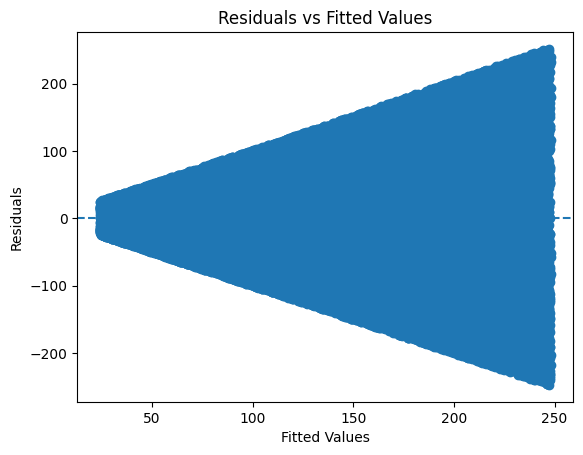

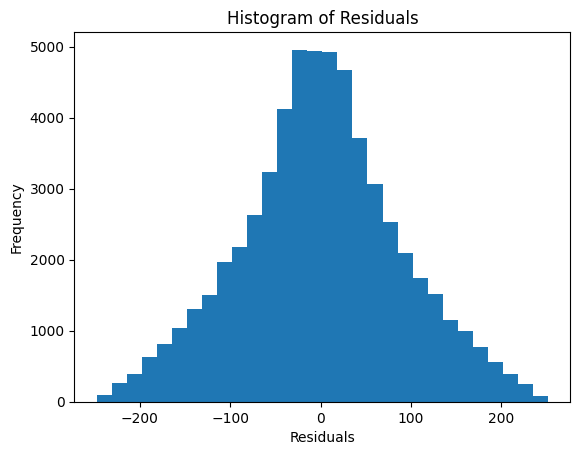

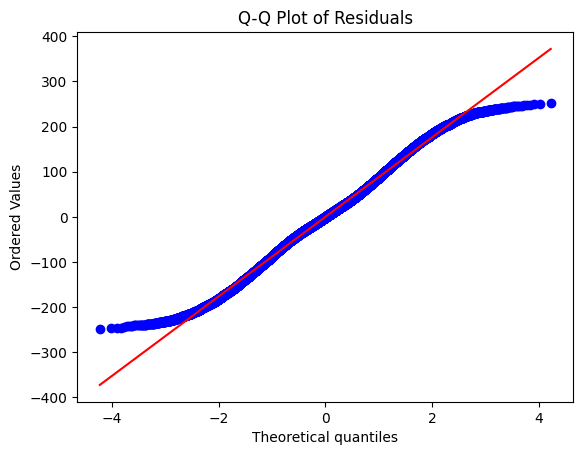

In [257]:
residuals = final_model.resid
fitted = final_model.fittedvalues

# Residuals vs fitted
plt.scatter(fitted, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Histogram of residuals
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [258]:
# Decision Trees

In [275]:
from sklearn.tree import DecisionTreeClassifier

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16)

DT = DecisionTreeClassifier()
DT2 = DecisionTreeClassifier()

DT.fit(X_train,y_train)

DT_Predictions_Train= DT.predict(X_train)
DT_Predictions_Test = DT.predict(X_test)

DT_Predictions_Train

array([ 97, 207, 249, ..., 115,  56, 100], shape=(58480,))

In [276]:
print("Accuracy Rate for the Training Set:", DT.score(X_train, y_train))
print("Accuracy Rate for the Test Set:", DT.score(X_test, y_test))

Accuracy Rate for the Training Set: 0.9930574555403556
Accuracy Rate for the Test Set: 0.004240766073871409


In [ ]:
# In this training set, 99.3% of records have been classified
# correctly. However the test set had 0.4% which indicates new
# data is not working. This could mean our decision tree is 
# overfitted.

In [265]:
# Random Forest

In [267]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1
)

RFC.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [268]:
RFC_Predictions_Train= RFC.predict(X_train)
RFC_Predictions_Test = RFC.predict(X_test)

In [269]:
RFC_Predictions_Train

array([ 97,  61,  66, ..., 115,  56, 433], shape=(58480,))

In [270]:
print("Accuracy Rate for the Training Set:", RFC.score(X_train, y_train))
print("Accuracy Rate for the Test Set:", RFC.score(X_test, y_test))

Accuracy Rate for the Training Set: 0.5734097127222982
Accuracy Rate for the Test Set: 0.004445964432284542


In [ ]:
# In this training set, 57.3% of records have been classified
# correctly. However the test set had 0.4% which indicates new
# data is not working. This could mean our decision tree is 
# overfitted.